# Demo: phân loại chữ số viết tay — CNN 2 tầng tích chập

**Mục tiêu.** Huấn luyện một mạng nơ-ron tích chập (CNN) nhỏ để nhận dạng chữ số
viết tay 0–9 từ ảnh xám **8×8**.

**Dữ liệu.** Tập `digits` của scikit-learn (`load_digits`): 1.797 ảnh 8×8 — "kiểu
MNIST" thu nhỏ, nhẹ và **có sẵn offline** (không cần tải qua mạng).

**Kiến trúc — CNN 2 tầng tích chập.** Ảnh đi qua 2 khối *tích chập → ReLU → gộp
cực đại*, rồi trải phẳng và đưa vào 2 tầng `Linear` để ra 10 logits:

| Tầng | Phép biến đổi | Kích thước ra | Tham số |
|------|---------------|---------------|--------:|
| `Conv2d(1→8, 3×3, pad 1)` | tích chập + ReLU | 8×8×8 | 80 |
| `MaxPool2d(2)` | gộp cực đại | 4×4×8 | 0 |
| `Conv2d(8→16, 3×3, pad 1)` | tích chập + ReLU | 4×4×16 | 1.168 |
| `MaxPool2d(2)` | gộp cực đại | 2×2×16 | 0 |
| `Flatten` | trải phẳng | 64 | 0 |
| `Linear(64→32)` + ReLU | tầng ẩn | 32 | 2.080 |
| `Linear(32→10)` | tầng output | 10 | 330 |
| **Tổng** | | | **3.658** |

So với `day2/mnist_torch.py` (chỉ gồm các tầng `Linear`), bài này thêm hai khối
nền tảng của CNN: **tầng tích chập** `Conv2d` (học các bộ lọc dò nét) và **gộp
cực đại** `MaxPool2d` (thu nhỏ ảnh, giữ đặc trưng mạnh nhất).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Cố định hạt giống ngẫu nhiên để kết quả tái lập được giữa các lần chạy.
SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Chuẩn bị dữ liệu

Mỗi ảnh là ma trận 8×8 với giá trị pixel trong khoảng `[0, 16]`. Ta chuẩn hóa về
`[0, 1]`, chia 80% train / 20% test (phân tầng theo nhãn để các lớp cân bằng),
rồi thêm chiều **kênh** `C=1` vì `Conv2d` cần đầu vào dạng `(N, C, H, W)`.

In [2]:
digits = load_digits()
print("Ảnh :", digits.images.shape, "| pixel trong [", int(digits.images.min()),
      ",", int(digits.images.max()), "]")
print("Nhãn:", digits.target.shape, "| các lớp:", np.unique(digits.target))

X = digits.images.astype("float32") / 16.0      # (1797, 8, 8) -> [0, 1]
y = digits.target.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# (N, 8, 8) -> (N, 1, 8, 8): thêm chiều kênh cho ảnh xám.
X_train = torch.tensor(X_train).unsqueeze(1)
X_test = torch.tensor(X_test).unsqueeze(1)
y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

print("\nTrain:", tuple(X_train.shape), "| Test:", tuple(X_test.shape))

Ảnh : (1797, 8, 8) | pixel trong [ 0 , 16 ]
Nhãn: (1797,) | các lớp: [0 1 2 3 4 5 6 7 8 9]

Train: (1437, 1, 8, 8) | Test: (360, 1, 8, 8)


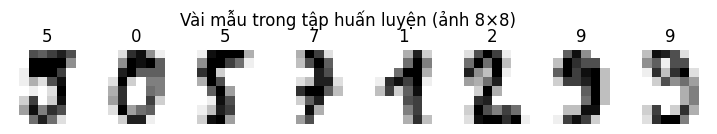

In [3]:
# Xem thử vài mẫu huấn luyện (cmap="gray_r": nét đậm = giá trị lớn).
fig, axes = plt.subplots(1, 8, figsize=(9, 1.6))
for ax, img, lab in zip(axes, X_train[:8, 0], y_train[:8]):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(int(lab))
    ax.axis("off")
fig.suptitle("Vài mẫu trong tập huấn luyện (ảnh 8×8)")
plt.show()

## 2. Định nghĩa mô hình CNN

- `Conv2d(in, out, 3, padding=1)`: học `out` bộ lọc 3×3 trượt trên ảnh; `padding=1`
  giữ nguyên kích thước không gian (8×8 → 8×8).
- `ReLU`: phi tuyến, giữ phần dương.
- `MaxPool2d(2)`: lấy giá trị lớn nhất trên mỗi ô 2×2 → giảm một nửa chiều dài/rộng.
- Sau 2 khối: ảnh còn `2×2×16 = 64` số → trải phẳng → 2 tầng `Linear` → 10 logits.

In [4]:
class DigitCNN(nn.Module):
    '''CNN 2 tầng tích chập cho ảnh chữ số 8×8.'''

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),   # (1,8,8)  -> (8,8,8)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # (8,8,8)  -> (8,4,4)
            nn.Conv2d(8, 16, kernel_size=3, padding=1),  # (8,4,4)  -> (16,4,4)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # (16,4,4) -> (16,2,2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # (16,2,2) -> 64
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10),                           # 10 logits
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = DigitCNN()

total_params = sum(p.numel() for p in model.parameters())
print(f"Tổng số tham số: {total_params:,}\n")
for name, p in model.named_parameters():
    print(f"  {name:24s} {str(tuple(p.shape)):16s} -> {p.numel():>5}")

Tổng số tham số: 3,658

  features.0.weight        (8, 1, 3, 3)     ->    72
  features.0.bias          (8,)             ->     8
  features.3.weight        (16, 8, 3, 3)    ->  1152
  features.3.bias          (16,)            ->    16
  classifier.1.weight      (32, 64)         ->  2048
  classifier.1.bias        (32,)            ->    32
  classifier.3.weight      (10, 32)         ->   320
  classifier.3.bias        (10,)            ->    10


## 3. Huấn luyện (30 epoch)

Mỗi epoch duyệt toàn bộ tập train theo các **batch** 64 ảnh. Hàm mất mát
`CrossEntropyLoss` (softmax + NLL) nhận trực tiếp logits; tối ưu bằng `Adam`.

In [5]:
EPOCHS = 30
BATCH_SIZE = 64

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
gen = torch.Generator().manual_seed(SEED)   # cố định thứ tự xáo trộn -> tái lập

n_batches = (len(X_train) + BATCH_SIZE - 1) // BATCH_SIZE
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(X_train), generator=gen)   # xáo trộn mỗi epoch
    running = 0.0
    for i in range(0, len(X_train), BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        logits = model(X_train[idx])
        loss = loss_fn(logits, y_train[idx])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:2d}/{EPOCHS} - loss trung bình: {running / n_batches:.4f}")

Epoch  1/30 - loss trung bình: 2.2966


Epoch  5/30 - loss trung bình: 1.8539


Epoch 10/30 - loss trung bình: 0.6150


Epoch 15/30 - loss trung bình: 0.2981


Epoch 20/30 - loss trung bình: 0.2106


Epoch 25/30 - loss trung bình: 0.1576


Epoch 30/30 - loss trung bình: 0.1220


## 4. Đánh giá trên tập kiểm tra

In [6]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    preds = test_logits.argmax(dim=1)
    accuracy = (preds == y_test).float().mean().item()

print(f"Độ chính xác trên tập kiểm tra: {100 * accuracy:.1f}%")

Độ chính xác trên tập kiểm tra: 95.3%


In [7]:
# Tóm tắt kết quả dưới dạng 3 thẻ thống kê (giống bản demo yêu cầu).
acc_str = f"{100 * accuracy:.1f}".replace(".", ",")     # 95,3
params_str = f"{total_params:,}".replace(",", ".")      # 3.658

cards = [
    ("#2e7d52", f"{acc_str}%",   "Độ chính xác trên tập kiểm tra"),
    ("#1b3a4b", params_str,      "Tổng số tham số của mô hình"),
    ("#d98324", str(EPOCHS),     "Số epoch huấn luyện"),
]
html = '<div style="display:flex;gap:16px;font-family:Georgia,serif;margin:8px 0;">'
for color, value, label in cards:
    html += (
        f'<div style="flex:1;background:#eef3ef;border-left:6px solid {color};'
        f'padding:18px 22px;border-radius:4px;">'
        f'<div style="font-size:40px;font-weight:700;color:{color};line-height:1;">{value}</div>'
        f'<div style="color:#3a3a3a;margin-top:10px;font-size:15px;">{label}</div></div>'
    )
html += "</div>"
display(HTML(html))

## 5. Trực quan hóa dự đoán

10 mẫu đầu tiên trong tập kiểm tra cùng nhãn mô hình dự đoán
(**xanh = dự đoán đúng**, **đỏ = dự đoán sai**).

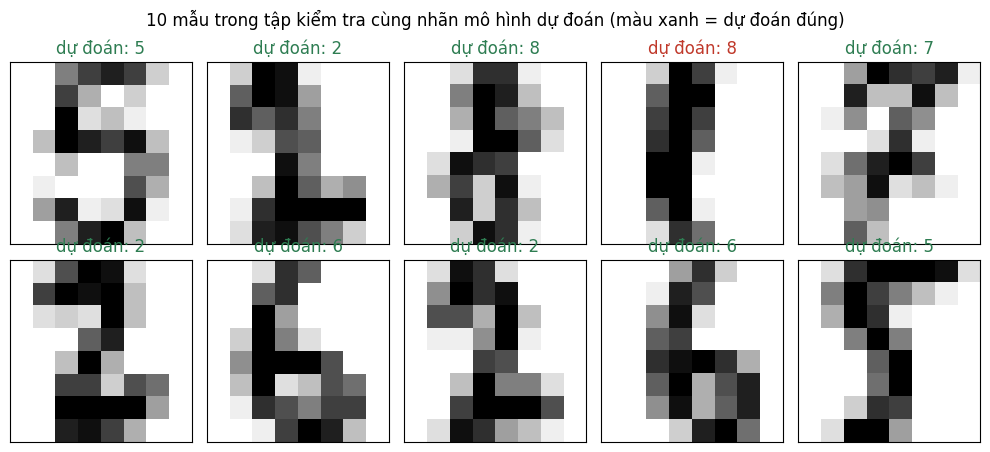

In [8]:
n_show = 10
fig, axes = plt.subplots(2, 5, figsize=(10, 4.6))
for ax, i in zip(axes.ravel(), range(n_show)):
    pred = preds[i].item()
    true = y_test[i].item()
    color = "#2e7d52" if pred == true else "#c0392b"   # xanh nếu đúng, đỏ nếu sai
    ax.imshow(X_test[i, 0], cmap="gray_r")
    ax.set_title(f"dự đoán: {pred}", color=color, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("10 mẫu trong tập kiểm tra cùng nhãn mô hình dự đoán "
             "(màu xanh = dự đoán đúng)", fontsize=12)
plt.tight_layout()
plt.show()